In [ ]:
%load_ext autoreload
%autoreload 2

import torch
import numpy as np
import pyro
import pyro.infer as infer
from pyro.infer import MCMC, NUTS

def enforce_reproducibility(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
    pyro.clear_param_store()
    pyro.set_rng_seed(seed)

In [2]:
import os
import sys
import arviz as az
import  matplotlib.pyplot as plt
#current folder path
current_notebook_dir = os.getcwd()
#find parent folder one level up
project_root_dir = os.path.abspath(os.path.join(current_notebook_dir, ".."))
if project_root_dir not in sys.path:
    sys.path.append(project_root_dir)
    print(f"Successfully added project root to path: {project_root_dir}")

from src.model import PhylogeneticPrior
from src.diagnostics import (
    evaluate_test_diagnostics,
    print_diagnostic_report,
    compute_nj_residual
)
from src.penalty import get_fresh_test_quartets


Successfully added project root to path: /Users/riyaaggarwal/Desktop/Block4/Block4 project/scripts/implementation


In [5]:
pyro.clear_param_store()
enforce_reproducibility(42)

# Global experimental parameters
params = {
    "N" : 50,
    "K" : 2,
    "B_train" : 500,
    "B_test" : 1000, 
    "lambda_4" : 3.0,     
    "lambda_g" : 1.0,   
    "sigma_u" : 1.0,  
    "warmup_steps" : 300, 
    "num_samples" : 500,  
    "target_accept_prob" : 0.80,
    "seed" : 42
}

# Base framework prior model initiation
prior_model = PhylogeneticPrior(
    N=params["N"],
    K=params["K"],
    B=params["B_train"],
    sigma_u=params["sigma_u"],
    seed=params["seed"]
)
print("Prior model parameters are:", prior_model)

# Fresh test quartets generated for validation
test_quartets = get_fresh_test_quartets(
    N=params["N"],
    B_test=params["B_test"],
    train_quartets=prior_model.fixed_indices,
    seed=123
)

def global_model_conditioned(current_tau):
    """Global wrapper function adapted for the Experiment 2 Temperature sweep."""
    # 🌟 The structural penalties belong right here inside the initialization phase!
    return prior_model.initialize(
        lmbda_4=params["lambda_4"], 
        lmbda_g=params["lambda_g"],
        tau=current_tau,       
        use_scale=False,
        g0=0.1
    )

# Dedicated temperature grid for the Experiment 2 sweep
tau_grid = [0.001, 0.01, 0.05, 0.1, 0.2, 0.5, 1.0]
results_experiment2_tau = {}

Prior model parameters are: <src.model.PhylogeneticPrior object at 0x158a5b810>



🚀 EXPERIMENT 2: Sweeping Smoothness Temperature τ = 0.001
  Generating initialization trajectory anchors from the base model...
  Running Chain 1/2...


Warmup:   0%|          | 0/800 [00:00, ?it/s]

  Catastrophic Numerical Freezing encountered at τ = 0.001
     Details: Model specification seems incorrect - cannot find valid initial params.
   Landscape Failure: Parameter optimization bounds too brittle at τ = 0.001

🚀 EXPERIMENT 2: Sweeping Smoothness Temperature τ = 0.01
  Generating initialization trajectory anchors from the base model...
  Running Chain 1/2...


Warmup:   0%|          | 0/800 [00:00, ?it/s]


  Catastrophic Numerical Freezing encountered at τ = 0.01
     Details: Model specification seems incorrect - cannot find valid initial params.
   Landscape Failure: Parameter optimization bounds too brittle at τ = 0.01

🚀 EXPERIMENT 2: Sweeping Smoothness Temperature τ = 0.05
  Generating initialization trajectory anchors from the base model...
  Running Chain 1/2...


Sample: 100%|██████████| 800/800 [03:43,  3.57it/s, step size=4.49e-02, acc. prob=0.767]


  Running Chain 2/2...


Sample: 100%|██████████| 800/800 [03:39,  3.65it/s, step size=3.49e-02, acc. prob=0.844]


  Merging sequential chains and computing convergence summaries...
    └─ Mean R-hat (Target ≤ 1.05): 1.0036
    └─ Minimum Bulk ESS: 646.0

[1] Hard Four-Point Violations v_q(D~):
  └─ Median Violation        : 0.0610
  └─ 95th Percentile (q_0.95): 0.2040
  └─ 99th Percentile         : 0.2440

[2] Approx Tree-Consistency Rate A(D~; ε=0.05):
  └─ Fraction Consistent     : 43.71%

[3] Quartet Gap Diagnostics g_q(D~):
  └─ Median Branch Gap       : 0.2785
  └─ 5th Percentile Gap      : 0.0224
  └─ Star-like Fraction (≤γ) : 10.91%

[4] Normalized Distance-Scale Diagnostics (Expect Mean=1.0):
  └─ Minimum Pairwise Dist   : 0.0049
  └─ Median Pairwise Dist    : 0.9596
  └─ Maximum Pairwise Dist   : 3.4531

    └─ Post-hoc Mean NJ Tree Residual R_NJ(D~): 159.865%


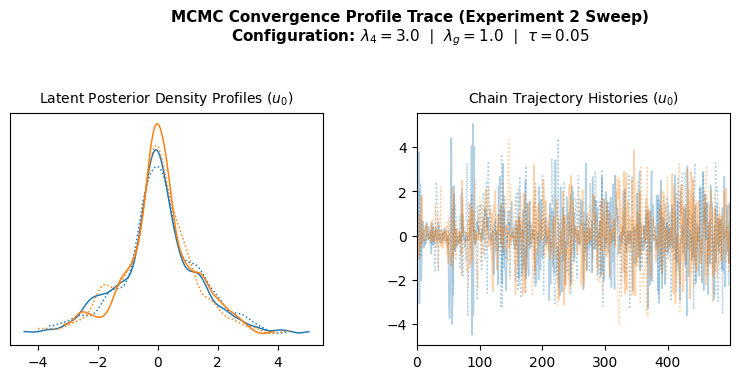


🚀 EXPERIMENT 2: Sweeping Smoothness Temperature τ = 0.1
  Generating initialization trajectory anchors from the base model...
  Running Chain 1/2...


Sample: 100%|██████████| 800/800 [17:18,  1.30s/it, step size=2.74e-02, acc. prob=0.846] 


  Running Chain 2/2...


Sample: 100%|██████████| 800/800 [04:15,  3.13it/s, step size=3.23e-02, acc. prob=0.819]


  Merging sequential chains and computing convergence summaries...
    └─ Mean R-hat (Target ≤ 1.05): 1.0042
    └─ Minimum Bulk ESS: 272.0

[1] Hard Four-Point Violations v_q(D~):
  └─ Median Violation        : 0.0595
  └─ 95th Percentile (q_0.95): 0.2018
  └─ 99th Percentile         : 0.2438

[2] Approx Tree-Consistency Rate A(D~; ε=0.05):
  └─ Fraction Consistent     : 44.46%

[3] Quartet Gap Diagnostics g_q(D~):
  └─ Median Branch Gap       : 0.2551
  └─ 5th Percentile Gap      : 0.0200
  └─ Star-like Fraction (≤γ) : 11.99%

[4] Normalized Distance-Scale Diagnostics (Expect Mean=1.0):
  └─ Minimum Pairwise Dist   : 0.0003
  └─ Median Pairwise Dist    : 0.9531
  └─ Maximum Pairwise Dist   : 3.7205

    └─ Post-hoc Mean NJ Tree Residual R_NJ(D~): 147.524%


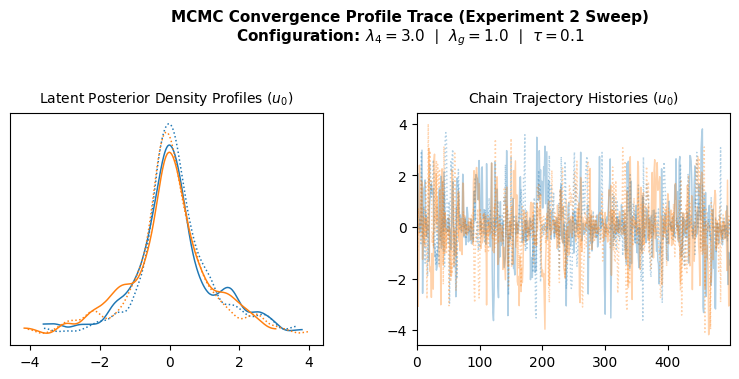


🚀 EXPERIMENT 2: Sweeping Smoothness Temperature τ = 0.2
  Generating initialization trajectory anchors from the base model...
  Running Chain 1/2...


Sample: 100%|██████████| 800/800 [24:40,  1.85s/it, step size=2.41e-02, acc. prob=0.806] 


  Running Chain 2/2...


Sample: 100%|██████████| 800/800 [16:48,  1.26s/it, step size=2.37e-02, acc. prob=0.833]


  Merging sequential chains and computing convergence summaries...
    └─ Mean R-hat (Target ≤ 1.05): 1.0057
    └─ Minimum Bulk ESS: 159.0

[1] Hard Four-Point Violations v_q(D~):
  └─ Median Violation        : 0.0541
  └─ 95th Percentile (q_0.95): 0.1924
  └─ 99th Percentile         : 0.2381

[2] Approx Tree-Consistency Rate A(D~; ε=0.05):
  └─ Fraction Consistent     : 47.42%

[3] Quartet Gap Diagnostics g_q(D~):
  └─ Median Branch Gap       : 0.2251
  └─ 5th Percentile Gap      : 0.0178
  └─ Star-like Fraction (≤γ) : 13.64%

[4] Normalized Distance-Scale Diagnostics (Expect Mean=1.0):
  └─ Minimum Pairwise Dist   : 0.0012
  └─ Median Pairwise Dist    : 0.9563
  └─ Maximum Pairwise Dist   : 4.1116

    └─ Post-hoc Mean NJ Tree Residual R_NJ(D~): 127.920%


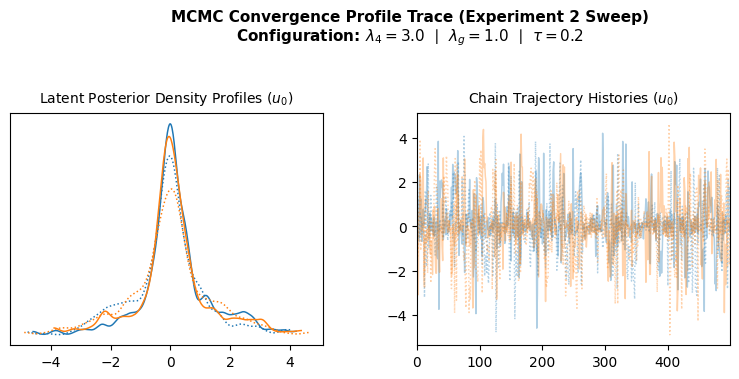


🚀 EXPERIMENT 2: Sweeping Smoothness Temperature τ = 0.5
  Generating initialization trajectory anchors from the base model...
  Running Chain 1/2...


Sample: 100%|██████████| 800/800 [09:43,  1.37it/s, step size=2.04e-02, acc. prob=0.850]


  Running Chain 2/2...


Sample: 100%|██████████| 800/800 [08:44,  1.53it/s, step size=2.12e-02, acc. prob=0.857]


  Merging sequential chains and computing convergence summaries...
    └─ Mean R-hat (Target ≤ 1.05): 1.0063
    └─ Minimum Bulk ESS: 82.0

[1] Hard Four-Point Violations v_q(D~):
  └─ Median Violation        : 0.0486
  └─ 95th Percentile (q_0.95): 0.1835
  └─ 99th Percentile         : 0.2359

[2] Approx Tree-Consistency Rate A(D~; ε=0.05):
  └─ Fraction Consistent     : 50.96%

[3] Quartet Gap Diagnostics g_q(D~):
  └─ Median Branch Gap       : 0.1944
  └─ 5th Percentile Gap      : 0.0149
  └─ Star-like Fraction (≤γ) : 15.84%

[4] Normalized Distance-Scale Diagnostics (Expect Mean=1.0):
  └─ Minimum Pairwise Dist   : 0.0009
  └─ Median Pairwise Dist    : 0.9591
  └─ Maximum Pairwise Dist   : 4.2575

    └─ Post-hoc Mean NJ Tree Residual R_NJ(D~): 102.368%


Warmup:   0%|          | 0/800 [1:30:16, ?it/s]


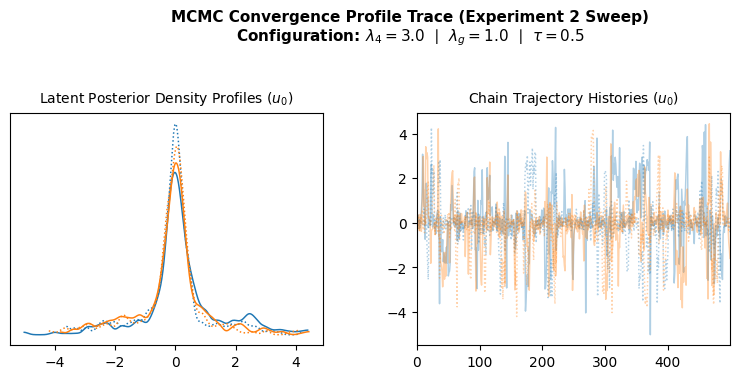


🚀 EXPERIMENT 2: Sweeping Smoothness Temperature τ = 1.0
  Generating initialization trajectory anchors from the base model...
  Running Chain 1/2...


Sample: 100%|██████████| 800/800 [08:23,  1.59it/s, step size=2.71e-02, acc. prob=0.789]


  Running Chain 2/2...


Sample: 100%|██████████| 800/800 [08:08,  1.64it/s, step size=2.92e-02, acc. prob=0.786]


  Merging sequential chains and computing convergence summaries...
    └─ Mean R-hat (Target ≤ 1.05): 1.0124
    └─ Minimum Bulk ESS: 50.0

[1] Hard Four-Point Violations v_q(D~):
  └─ Median Violation        : 0.0466
  └─ 95th Percentile (q_0.95): 0.1780
  └─ 99th Percentile         : 0.2319

[2] Approx Tree-Consistency Rate A(D~; ε=0.05):
  └─ Fraction Consistent     : 52.37%

[3] Quartet Gap Diagnostics g_q(D~):
  └─ Median Branch Gap       : 0.1837
  └─ 5th Percentile Gap      : 0.0143
  └─ Star-like Fraction (≤γ) : 16.62%

[4] Normalized Distance-Scale Diagnostics (Expect Mean=1.0):
  └─ Minimum Pairwise Dist   : 0.0009
  └─ Median Pairwise Dist    : 0.9664
  └─ Maximum Pairwise Dist   : 4.6943

    └─ Post-hoc Mean NJ Tree Residual R_NJ(D~): 92.681%


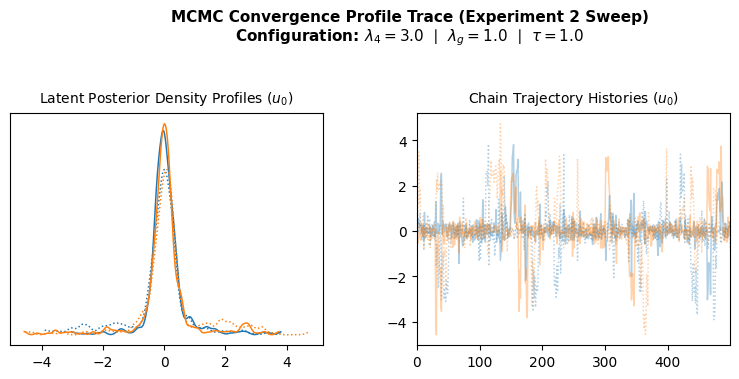

In [8]:
# 🔬 EXPERIMENT 2: ROBUST TEMPERATURE SWEEP LOOP (WITH INITIALIZATION SAFETY)
import numpy as np
import torch
import pyro
import pyro.infer as infer
from pyro.infer import MCMC, NUTS
import arviz as az

for current_tau in tau_grid:
    print(f"\n🚀 EXPERIMENT 2: Sweeping Smoothness Temperature τ = {current_tau}")
    
    def current_model_conditioned():
        return global_model_conditioned(current_tau)

    # STEP 1: Generate a valid empirical warmup anchor using the prior framework
    print("  Generating initialization trajectory anchors from the base model...")
    try:
        # Trace a single unpenalized sequence execution path to extract coordinate dimensions
        model_trace = pyro.poutine.trace(current_model_conditioned).get_trace()
        
        # Pull out the exact raw string dictionary names of your latent variables
        init_values = {
            name: node["value"].detach().clone()
            for name, node in model_trace.nodes.items()
            if node["type"] == "sample" and not node["is_observed"]
        }
        
        # Define an isolated conditioning factory to pass these coordinates directly
        def init_strategy(site):
            return init_values.get(site["name"])
            
    except Exception as init_err:
        print(f"  ⚠️ Pre-initialization path building failed: {init_err}")
        init_strategy = None

    chain_idatas = []
    total_divergences = 0
    all_posterior_samples = []

    # Run independent sequential chains
    for chain_idx in range(2):
        print(f"  Running Chain {chain_idx + 1}/2...")
        enforce_reproducibility(params["seed"] + chain_idx)

        # 🌟 STEP 2: Pass our structural init_strategy function directly to the NUTS engine
        nuts_kernel = NUTS(
            current_model_conditioned, 
            adapt_step_size=True, 
            target_accept_prob=params["target_accept_prob"],
            init_strategy=init_strategy if init_strategy is not None else "uniform"
        )
        
        mcmc = MCMC(
            kernel=nuts_kernel,
            num_samples=params["num_samples"],
            warmup_steps=params["warmup_steps"],
            num_chains=1,  
        )
        
        # 🌟 STEP 3: Wrap the main runtime execution block inside an overflow capture envelope
        try:
            mcmc.run()
        except (ValueError, RuntimeError) as run_error:
            print(f"  Catastrophic Numerical Freezing encountered at τ = {current_tau}")
            print(f"     Details: {run_error}")
            break # Breaks out of the current parameter chain loop cleanly
        
        chain_idata = az.from_pyro(mcmc, log_likelihood=False)
        chain_idatas.append(chain_idata)
        all_posterior_samples.append(mcmc.get_samples())

        div_list = mcmc.diagnostics().get("divergences", [])
        if isinstance(div_list, dict):
            total_divergences += len(div_list.get("chain 0", []))
        else:
            total_divergences += len(div_list) if div_list is not None else 0

    # If a run crashed or returned empty coordinates, log the failure point elegantly
    if len(chain_idatas) < 2:
        print(f"   Landscape Failure: Parameter optimization bounds too brittle at τ = {current_tau}")
        results_experiment2_tau[current_tau] = {"metrics": None, "mean_nj_residual": np.nan, "divergences": "ALL"}
        continue

    print("  Merging sequential chains and computing convergence summaries...")
    idata = az.concat(chain_idatas[0], chain_idatas[1], dim="chain")
    summary_stats = az.summary(idata, var_names=["u"])
    
    mean_rhat = summary_stats["r_hat"].mean()
    min_ess_bulk = summary_stats["ess_bulk"].min()
    
    print(f"    └─ Mean R-hat (Target ≤ 1.05): {mean_rhat:.4f}")
    print(f"    └─ Minimum Bulk ESS: {min_ess_bulk:.1f}")

    # Generate well-spaced predictive draws
    D_samples_list = []
    sample_indices = np.linspace(0, params["num_samples"] - 1, 75, dtype=int)
    
    for chain_samples in all_posterior_samples:
        for s in sample_indices:
            single_sample = {k: v[s:s+1] for k, v in chain_samples.items()}
            try:
                predictive = infer.Predictive(current_model_conditioned, posterior_samples=single_sample)
                single_pred = predictive()
                D_matrix = single_pred["D_tilde"].squeeze(0)
                
                if torch.isnan(D_matrix).any() or torch.isinf(D_matrix).any():
                    continue
                D_samples_list.append(D_matrix.detach().cpu().numpy())
            except Exception:
                continue

    if len(D_samples_list) == 0:
        print(f"  Post-hoc Evaluation Failure: Total numerical overflow at τ = {current_tau}")
        results_experiment2_tau[current_tau] = {"metrics": None, "mean_nj_residual": np.nan, "divergences": "ALL"}
        continue
        
    D_samples = torch.stack([
        torch.as_tensor(d, dtype=torch.float32).reshape(params["N"], params["N"]) 
        for d in D_samples_list
    ])

    metrics = evaluate_test_diagnostics(D_samples, test_quartets, epsilon=0.05, gamma=0.05)
    print_diagnostic_report(metrics, epsilon=0.05, gamma=0.05)
    
    nj_residuals = [compute_nj_residual(D_samples[i]) for i in range(D_samples.shape[0])]
    mean_nj_residual = np.mean(nj_residuals)
    print(f"    └─ Post-hoc Mean NJ Tree Residual R_NJ(D~): {mean_nj_residual * 100:.3f}%")
    
    results_experiment2_tau[current_tau] = {
        "metrics": metrics,
        "mean_nj_residual": mean_nj_residual,
        "divergences": total_divergences,
        "arviz_summary": summary_stats,
        "mean_rhat": mean_rhat,
        "min_ess": min_ess_bulk
    }

    # Render caterpillar profile tracks
    axes_grid = az.plot_trace(
        idata, 
        var_names=["u"], 
        coords={"u_dim_0": [0], "u_dim_1": [0, 1]},
        compact=True,
        backend_kwargs={"figsize": (10, 4)}
    )
    axes = axes_grid.flatten()
    axes[0].set_title(r"Latent Posterior Density Profiles ($u_{0}$)", fontsize=10, pad=8)
    axes[1].set_title(r"Chain Trajectory Histories ($u_{0}$)", fontsize=10, pad=8)
    
    fig = axes[0].get_figure()
    fig.suptitle(
        fr"MCMC Convergence Profile Trace (Experiment 2 Sweep)" + "\n" +
        fr"Configuration: $\lambda_4 = {params['lambda_4']}$ $\mid$ $\lambda_g = {params['lambda_g']}$ $\mid$ $\tau = {current_tau}$", 
        y=1.02, fontsize=11, weight='bold'
    )
    fig.subplots_adjust(top=0.76, bottom=0.18, left=0.10, right=0.82, wspace=0.30)
    plt.show()

